# Part A 강건성 점검 실행본
`shipbuilding_quant_case_1.ipynb`에서 **강건성 점검 셀과 그 선행 셀만** 실행한 사본입니다.
- 선행 셀: 설정, 주가 수집, Part A 계산(V0·레짐), A2 함수, DART 수집, 이벤트 함수, Part C 설정(`backtest`, `metrics`)
- 그림·CSV를 루트에 저장하는 기존 셀(A1 그림, H1·H2, H3, 결과 저장, C 전략)은 실행하지 않음 → 기존 결과 파일 보존

In [1]:
import os, time, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 110

DART_API_KEY = os.environ["DART_API_KEY"]    # 환경변수에서 읽음 (키 문자열을 노트북·출력에 남기지 않음)
assert DART_API_KEY.strip(), "환경변수 DART_API_KEY가 비어 있습니다"
START = "2015-01-01"
END   = pd.Timestamp.today().strftime("%Y-%m-%d")
RES_DIR = "results"                          # Part D·E 그래프·표 저장 폴더
os.makedirs(RES_DIR, exist_ok=True)

# 조선 유니버스  종목코드: (그래프용 영문 라벨, 그룹)
# 합병·상장폐지된 종목은 데이터가 있는 기간까지만 자동 사용됨
UNIVERSE = {
    "009540": ("HD KSOE(Hold)",  "HD"),
    "329180": ("HD HHI",         "HD"),
    "010620": ("HD Mipo",        "HD"),
    "010140": ("Samsung HI",     "SHI"),
    "042660": ("Hanwha Ocean",   "HANWHA"),
    "097230": ("HJ Shipbuilding","HJ"),
}
NAME  = {k: v[0] for k, v in UNIVERSE.items()}
GROUP = {k: v[1] for k, v in UNIVERSE.items()}

# 지주사는 자회사와 기계적으로 상관이 높아 동조화 계산에서 제외
CORR_EXCLUDE = ["009540"]
# HJ중공업은 건설부문 공급계약도 같은 이름으로 공시되므로 이벤트 스터디 기본값에서 제외
EVENT_TICKERS = ["009540", "329180", "010620", "010140", "042660"]

ROLL_WIN    = 60          # 동조화 롤링 윈도우(거래일)
EST_WIN     = (-250, -30) # 시장모형 추정구간
EVT_WIN     = (-10, 10)   # 이벤트 윈도우
MIN_EST_OBS = 120
REL = np.arange(EVT_WIN[0], EVT_WIN[1] + 1)

In [2]:
def _load_one(ticker, start, end):
    s, e = start.replace("-", ""), end.replace("-", "")
    try:
        from pykrx import stock
        df = stock.get_market_ohlcv(s, e, ticker)          # adjusted=True 기본
        if df is not None and not df.empty:
            return df.rename(columns={"종가": "Close", "거래량": "Volume"})[["Close", "Volume"]]
    except Exception as ex:
        print(f"  pykrx 실패({ticker}): {ex}")
    try:
        import FinanceDataReader as fdr
        df = fdr.DataReader(ticker, start, end)
        if df is not None and not df.empty:
            print(f"  FDR 사용({ticker})")
            return df[["Close", "Volume"]]
    except Exception as ex:
        print(f"  FDR 실패({ticker}): {ex}")
    return None

def _load_kospi(start, end):
    try:
        from pykrx import stock
        df = stock.get_index_ohlcv(start.replace("-", ""), end.replace("-", ""), "1001")
        if df is not None and not df.empty:
            return df["종가"].rename("KOSPI")
    except Exception as ex:
        print(f"  pykrx 지수 실패: {ex}")
    import FinanceDataReader as fdr
    return fdr.DataReader("KS11", start, end)["Close"].rename("KOSPI")

def load_all(universe, start, end):
    close, vol = {}, {}
    for t in universe:
        print(f"loading {t} {NAME[t]}")
        df = _load_one(t, start, end)
        if df is None:
            print(f"  -> {t} 제외")
            continue
        close[t], vol[t] = df["Close"], df["Volume"]
        time.sleep(0.3)
    kospi = _load_kospi(start, end)
    kospi.index = pd.to_datetime(kospi.index)
    close = pd.DataFrame(close); close.index = pd.to_datetime(close.index)
    vol   = pd.DataFrame(vol);   vol.index   = pd.to_datetime(vol.index)
    return close.reindex(kospi.index), vol.reindex(kospi.index), kospi

def to_returns(close, vol, kospi, cap=0.30, tol=0.005):
    ret = close.pct_change(fill_method=None)
    ret = ret.mask((vol == 0) | vol.isna())
    # 정확히 ±30%인 상·하한가는 정상 관측치 → 부동소수점(1.3-1=0.30000000000000004)·수정주가 반올림 오차만큼 허용
    bad = ret.abs() > cap + tol
    if int(bad.values.sum()):
        print(f"|일간수익률| > {cap + tol:.1%} 관측치 {int(bad.values.sum())}개 NaN 처리")
    ret = ret.mask(bad)
    mkt = kospi.pct_change(fill_method=None)
    return ret, mkt

In [3]:
close, vol, kospi = load_all(UNIVERSE, START, END)
ret, mkt = to_returns(close, vol, kospi)
print("\n종목별 유효 수익률 관측치:")
print(ret.notna().sum().rename(NAME))

loading 009540 HD KSOE(Hold)
KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


loading 329180 HD HHI


loading 010620 HD Mipo


loading 010140 Samsung HI


loading 042660 Hanwha Ocean


loading 097230 HJ Shipbuilding


Error occurred in get_index_ohlcv_by_date: Expecting value: line 1 column 1 (char 0)
Error occurred in __fetch: Expecting value: line 1 column 1 (char 0)
  pykrx 지수 실패: '지수명'



종목별 유효 수익률 관측치:
HD KSOE(Hold)      2849
HD HHI             1221
HD Mipo            2676
Samsung HI         2862
Hanwha Ocean       2559
HJ Shipbuilding    2814
dtype: int64


In [4]:
def rolling_avg_corr(x, window=60, min_assets=3, min_frac=0.8):
    vals = np.full(len(x), np.nan)
    for i in range(window - 1, len(x)):
        sub = x.iloc[i - window + 1:i + 1]
        sub = sub.loc[:, sub.notna().sum() >= int(window * min_frac)]
        if sub.shape[1] < min_assets:
            continue
        c = sub.corr().values
        iu = np.triu_indices(c.shape[0], 1)
        vals[i] = np.nanmean(c[iu])
    return pd.Series(vals, index=x.index)

corr_cols = [c for c in ret.columns if c not in CORR_EXCLUDE]
ex_ret  = ret[corr_cols].sub(mkt, axis=0)                  # 시장조정수익률
theme     = rolling_avg_corr(ex_ret,       ROLL_WIN).rename("theme (market-adj)")
theme_raw = rolling_avg_corr(ret[corr_cols], ROLL_WIN).rename("raw corr")

theme_rank = theme.expanding(min_periods=250).rank(pct=True)
def to_regime(r):
    return pd.cut(r, [0, 0.2, 0.8, 1.0], labels=["Low", "Mid", "High"], include_lowest=True)
regime = to_regime(theme_rank)

sector_ex = ex_ret.mean(axis=1, skipna=True)               # 동일가중 섹터 초과수익
print(theme.describe())
print("\n레짐 분포:\n", regime.value_counts())

count   2,816.0000
mean        0.4301
std         0.1126
min         0.0958
25%         0.3414
50%         0.4330
75%         0.5173
max         0.7562
Name: theme (market-adj), dtype: float64

레짐 분포:
 theme (market-adj)
Mid     1572
High     644
Low      351
Name: count, dtype: int64


In [5]:
def fwd_sum(s, h):
    return s.rolling(h, min_periods=int(h * 0.8)).sum().shift(-h)

def nw_mean(y, lags):
    y = y.dropna()
    if len(y) < 30:
        return np.nan, np.nan, len(y)
    res = sm.OLS(y.values, np.ones(len(y))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res.params[0], res.tvalues[0], len(y)

def nw_diff(y, is_high, lags):
    d = pd.concat([y, is_high.astype(float)], axis=1).dropna()
    X = sm.add_constant(d.iloc[:, 1].values)
    res = sm.OLS(d.iloc[:, 0].values, X).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res.params[1], res.tvalues[1]

rows = []
for h in [5, 20, 60]:
    f = fwd_sum(sector_ex, h)
    for g in ["Low", "Mid", "High"]:
        m, t, n = nw_mean(f[regime == g], h)
        rows.append({"horizon": f"{h}d", "regime": g, "mean fwd excess(%)": m * 100, "NW t": t, "N(days)": n})
    sub = regime.isin(["Low", "High"])
    d, t = nw_diff(f[sub], (regime[sub] == "High"), h)
    rows.append({"horizon": f"{h}d", "regime": "High − Low", "mean fwd excess(%)": d * 100, "NW t": t, "N(days)": np.nan})
tblA2 = pd.DataFrame(rows).set_index(["horizon", "regime"])
display(tblA2)
print("해석: High − Low가 음수이고 |t| > 2 → 테마 과열 후 반전(A2 지지)")

mean fwd excess(%)    NW t    N(days)
horizon regime                                           
5d      Low                    -0.3137 -0.8218   351.0000
        Mid                     0.3397  1.4286 1,572.0000
        High                   -0.1442 -0.3771   639.0000
        High − Low              0.1695  0.3127        NaN
20d     Low                     0.9212  0.6345   351.0000
        Mid                     0.7770  0.9601 1,572.0000
        High                   -0.5278 -0.3503   624.0000
        High − Low             -1.4490 -0.6972        NaN
60d     Low                    -1.7842 -0.5959   351.0000
        Mid                     2.4696  1.0400 1,572.0000
        High                    1.1981  0.2369   584.0000
        High − Low              2.9823  0.5183        NaN

해석: High − Low가 음수이고 |t| > 2 → 테마 과열 후 반전(A2 지지)


In [6]:
import OpenDartReader
dart = OpenDartReader(DART_API_KEY)

def fetch_contracts(ticker):
    df = None
    for kind in ["I", ""]:
        try:
            df = dart.list(ticker, start=START, end=END, kind=kind, final=False)
            if df is not None and not df.empty:
                break
        except Exception as ex:
            print(f"  DART 실패({ticker}, kind={kind!r}): {ex}")
    if df is None or df.empty:
        return pd.DataFrame()
    nm = df["report_nm"].astype(str)
    m = (nm.str.contains("단일판매") & nm.str.contains("공급계약") & nm.str.contains("체결")
         & ~nm.str.contains("정정") & ~nm.str.contains("해지"))
    out = df.loc[m, ["rcept_no", "rcept_dt", "report_nm"]].copy()
    out["ticker"] = ticker
    return out

raw = []
for t in EVENT_TICKERS:
    if t not in ret.columns:
        continue
    r = fetch_contracts(t)
    print(f"{t} {NAME[t]}: 수주 공시 {len(r)}건")
    raw.append(r); time.sleep(0.5)
raw = pd.concat(raw, ignore_index=True)
raw["rcept_dt"] = pd.to_datetime(raw["rcept_dt"].astype(str))
raw.head()

009540 HD KSOE(Hold): 수주 공시 249건


329180 HD HHI: 수주 공시 90건


010620 HD Mipo: 수주 공시 134건


010140 Samsung HI: 수주 공시 164건


042660 Hanwha Ocean: 수주 공시 136건


,rcept_no,rcept_dt,report_nm,ticker
0,20260824800125,2026-08-24,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540
1,20260810800150,2026-08-10,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540
2,20260713800202,2026-07-13,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540
3,20260709800139,2026-07-09,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540
4,20260701800239,2026-07-01,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540


In [7]:
def build_events(raw, cal, gap=None):
    gap = gap or abs(EVT_WIN[0])
    raw = raw.copy()
    p = cal.searchsorted(raw["rcept_dt"])                # 공시일 이후 첫 거래일
    raw["tdate"] = [cal[i] if i < len(cal) else pd.NaT for i in p]
    ev = (raw.dropna(subset=["tdate"])
             .groupby(["ticker", "tdate"])
             .agg(n_contracts=("rcept_no", "size"), rcept_no=("rcept_no", "first"),
                  report_nm=("report_nm", "first"))
             .reset_index())
    ev["pos"] = [cal.get_loc(d) for d in ev["tdate"]]
    ev = ev.sort_values(["ticker", "tdate"]).reset_index(drop=True)
    prev_gap = ev.groupby("ticker")["pos"].diff()
    next_gap = -ev.groupby("ticker")["pos"].diff(-1)
    ev["clean"] = (prev_gap.isna() | (prev_gap > gap)) & (next_gap.isna() | (next_gap > gap))
    return ev

events = build_events(raw, ret.index)
print(f"이벤트 {len(events)}개 (clean {events['clean'].sum()}개)")
display(pd.crosstab(events["tdate"].dt.year, events["ticker"].map(NAME)))

이벤트 692개 (clean 193개)


ticker,HD HHI,HD KSOE(Hold),HD Mipo,Hanwha Ocean,Samsung HI
tdate,,,,,
2015,0,5,9,7,16
2016,0,1,1,5,4
2017,0,1,4,5,9
2018,0,5,6,9,14
2019,0,13,11,7,16
2020,0,17,9,7,9
2021,4,35,16,18,19
2022,14,30,16,17,17
2023,15,25,18,8,8


In [8]:
def market_model_ar(r, m, pos):
    n = len(r)
    if pos + EST_WIN[0] < 0 or pos + EVT_WIN[1] >= n:
        return None
    y = r.iloc[pos + EST_WIN[0]: pos + EST_WIN[1] + 1].values
    x = m.iloc[pos + EST_WIN[0]: pos + EST_WIN[1] + 1].values
    ok = ~np.isnan(y) & ~np.isnan(x)
    if ok.sum() < MIN_EST_OBS:
        return None
    beta, alpha = np.polyfit(x[ok], y[ok], 1)
    ry = r.iloc[pos + EVT_WIN[0]: pos + EVT_WIN[1] + 1].values
    rx = m.iloc[pos + EVT_WIN[0]: pos + EVT_WIN[1] + 1].values
    ar = ry - (alpha + beta * rx)
    if np.isnan(ar).sum() > 2:          # 이벤트 윈도우에 결측 3일 이상이면 제외
        return None
    return np.nan_to_num(ar)

def run_event_study(ev, ret, mkt):
    paths, keep = [], []
    for i, e in ev.iterrows():
        if e["ticker"] not in ret.columns:
            continue
        ar = market_model_ar(ret[e["ticker"]], mkt, int(e["pos"]))
        if ar is not None:
            paths.append(ar); keep.append(i)
    return pd.DataFrame(paths, index=keep, columns=REL)

def car(AR, a, b):
    return AR.loc[:, a:b].sum(axis=1)

WINDOWS = {"[-10,-1] pre": (-10, -1), "[-5,-1] pre": (-5, -1), "[0,+1] announce": (0, 1),
           "[+2,+10] post": (2, 10), "[-10,+10] total": (-10, 10)}

def car_table(AR):
    rows = []
    for name, (a, b) in WINDOWS.items():
        c = car(AR, a, b)
        t, p = stats.ttest_1samp(c, 0) if len(c) > 2 else (np.nan, np.nan)
        wp = stats.wilcoxon(c).pvalue if len(c) > 10 else np.nan
        rows.append({"window": name, "mean CAR(%)": c.mean() * 100, "median(%)": c.median() * 100,
                     "t": t, "p": p, "wilcoxon p": wp, "% positive": (c > 0).mean() * 100, "N": len(c)})
    return pd.DataFrame(rows).set_index("window")

def plot_car(AR_dict, title, fname):
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for label, AR in AR_dict.items():
        if len(AR) < 3:
            continue
        cp = AR.cumsum(axis=1)
        mu = cp.mean() * 100
        se = cp.std() / np.sqrt(len(cp)) * 100
        ax.plot(REL, mu, marker="o", ms=3, label=f"{label} (N={len(cp)})")
        ax.fill_between(REL, mu - 1.96 * se, mu + 1.96 * se, alpha=0.15)
    ax.axvline(0, color="k", lw=0.8, ls="--"); ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlabel("trading days relative to disclosure"); ax.set_ylabel("mean CAR (%)")
    ax.set_title(title); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(fname, bbox_inches="tight"); plt.show()

In [9]:
COST_BUY  = 0.00015              # 매수 수수료
COST_SELL = 0.00015 + 0.0015     # 매도 수수료 + 거래세 (※ 최신 세율 확인 후 수정)
IS_END    = "2020-12-31"         # 여기까지 In-sample, 이후 Out-of-sample

sector_ret = ret[corr_cols].mean(axis=1, skipna=True).fillna(0)   # 동일가중 조선 섹터
bench      = mkt.fillna(0)

def backtest(weight, asset_ret, cost_buy=COST_BUY, cost_sell=COST_SELL):
    w = weight.shift(1).fillna(0).clip(0, 1)          # t 신호 → t+1 적용
    dw = w.diff().fillna(w)
    cost = dw.clip(lower=0) * cost_buy + (-dw).clip(lower=0) * cost_sell
    gross = w * asset_ret
    return pd.DataFrame({"w": w, "gross": gross, "net": gross - cost, "cost": cost})

def metrics(r, name="", rf=0.0):
    r = r.dropna()
    if len(r) < 60:
        return {}
    cum = (1 + r).prod()
    yrs = len(r) / 252
    cagr = cum ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod()
    mdd = (eq / eq.cummax() - 1).min()
    return {"strategy": name, "CAGR(%)": cagr * 100, "Vol(%)": vol * 100,
            "Sharpe": (cagr - rf) / vol if vol > 0 else np.nan, "MDD(%)": mdd * 100,
            "Calmar": cagr / abs(mdd) if mdd < 0 else np.nan,
            "Hit(%)": (r > 0).mean() * 100, "Days": len(r)}

---
# Part A 강건성 점검 (사후 점검)
원래 Part A 결과는 **그대로 두고**, 테마 강도 정의의 세 가지 약점을 바꿔 가며 결론이 유지되는지 봅니다.
결과가 좋게 나와도 원래 결과를 대체하지 않습니다.

| 버전 | 구성 | 시장 조정 |
|---|---|---|
| **V0 원본** | HD현대중공업·HD현대미포·삼성중공업·한화오션·HJ중공업 (구성 변화 있음) | 종목 − KOSPI |
| **V1 대형 3사** | HD한국조선해양·삼성중공업·한화오션 (전 기간 고정) | 종목 − KOSPI |
| **V2 대형 3사 + 베타** | V1과 동일 | t−1일까지 250거래일 롤링 회귀 잔차 |

60일 창, 80% 관측 요건, expanding 백분위 레짐, 상·하위 20%는 원본과 같습니다. 결과는 `results/robust_A/`에 저장합니다.

In [10]:
# ===== RA1. 세 버전의 테마 강도 =====
ROB_DIR = os.path.join(RES_DIR, "robust_A"); os.makedirs(ROB_DIR, exist_ok=True)
BIG3 = ["009540", "010140", "042660"]          # HD한국조선해양, 삼성중공업, 한화오션
BETA_WIN = 250
BETA_MINP = int(BETA_WIN * 0.8)                 # 베타 창에도 원본과 같은 80% 관측 요건
VERS = ["V0 original", "V1 big3", "V2 big3 beta-adj"]

def lagged_beta_resid(r, m, win=BETA_WIN, minp=BETA_MINP):
    """t일 잔차 = r_t − (α + β·m_t). α·β는 t−1일까지 win일(종목·KOSPI 둘 다 관측된 날)로 추정."""
    x, y = m.where(r.notna()), r.where(m.notna())
    roll = lambda z: z.rolling(win, min_periods=minp).sum()
    n = x.notna().astype(float).rolling(win, min_periods=minp).sum()
    sx, sy, sxx, sxy = roll(x), roll(y), roll(x * x), roll(x * y)
    b = (sxy - sx * sy / n) / (sxx - sx * sx / n)
    a = (sy - b * sx) / n
    beta, alpha = b.shift(1), a.shift(1)      # t일 값에는 t일 데이터가 들어가지 않음
    return r - (alpha + beta * m), beta

ex_v1 = ret[BIG3].sub(mkt, axis=0)
_res, _bet = {}, {}
for t in BIG3:
    _res[t], _bet[t] = lagged_beta_resid(ret[t], mkt)
ex_v2, betas = pd.DataFrame(_res), pd.DataFrame(_bet)

theme_v0_check = rolling_avg_corr(ex_ret, ROLL_WIN)
print("V0 재현 확인 — 기존 theme와의 최대 차이:", float((theme_v0_check - theme).abs().max()))
THEME = {"V0 original": theme,
         "V1 big3": rolling_avg_corr(ex_v1, ROLL_WIN),
         "V2 big3 beta-adj": rolling_avg_corr(ex_v2, ROLL_WIN)}
RANK = {v: s.expanding(min_periods=250).rank(pct=True) for v, s in THEME.items()}
REGIME = {v: to_regime(r) for v, r in RANK.items()}
print("\n베타(t−1일까지 250일 추정) 요약")
display(betas.describe().T[["count", "mean", "min", "max"]].rename(index=NAME))
pd.DataFrame({**{f"theme {v}": s for v, s in THEME.items()},
              **{f"rank {v}": r for v, r in RANK.items()},
              **{f"regime {v}": g for v, g in REGIME.items()},
              **{f"beta {NAME[t]}": betas[t] for t in BIG3}}).to_csv(f"{ROB_DIR}/RA1_theme_series.csv", encoding="utf-8-sig")

V0 재현 확인 — 기존 theme와의 최대 차이: 0.0



베타(t−1일까지 250일 추정) 요약


,count,mean,min,max
HD KSOE(Hold),"2,674.0000",1.1828,0.4917,1.7807
Samsung HI,"2,674.0000",1.1355,0.5827,2.1818
Hanwha Ocean,"2,210.0000",1.1747,0.5090,1.8345


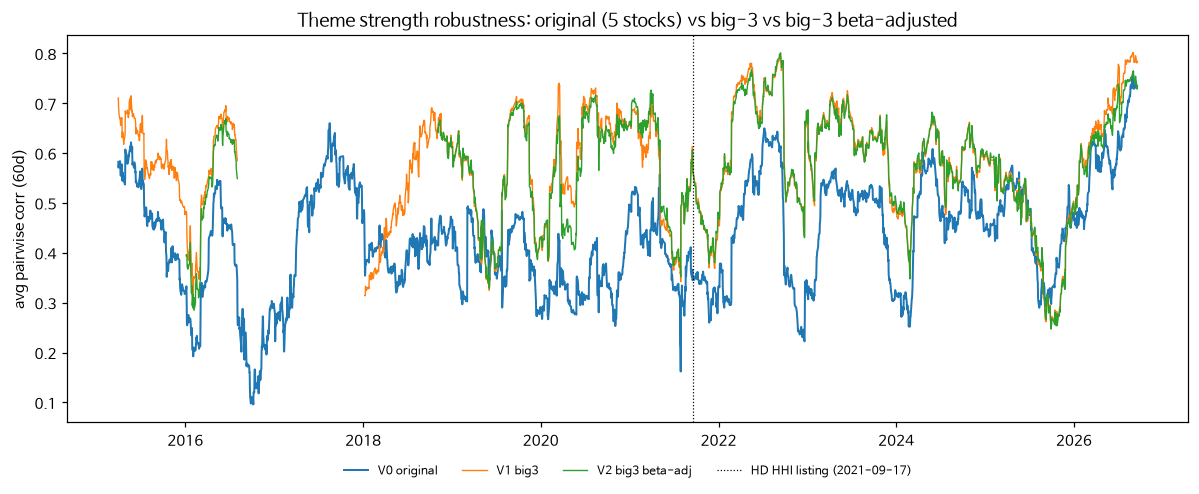

,first valid,valid days,mean,min,max,corr with V0,overlap days,High days,Low days
version,,,,,,,,,
V0 original,2015-03-31,2816,0.4301,0.0958,0.7562,1.0000,2816,644,351
V1 big3,2015-03-31,2466,0.5730,0.2487,0.8018,0.6252,2466,516,397
V2 big3 beta-adj,2016-01-04,2077,0.5701,0.2470,0.8012,0.6434,2077,452,263


V1·V2의 High 일 중 V0도 High인 비율: {'V1 big3': '54%', 'V2 big3 beta-adj': '58%'}


V0 original            V1 big3        V2 big3 beta-adj       
         date  theme        date  theme             date  theme
0  2026-08-31 0.7562  2026-08-31 0.8018       2022-09-13 0.8012
1  2017-08-16 0.6602  2022-09-13 0.7944       2022-05-16 0.7672
2  2022-07-08 0.6498  2022-05-12 0.7804       2026-09-02 0.7651
3  2026-05-06 0.6471  2020-03-16 0.7402       2021-03-29 0.7265
4  2015-05-22 0.6216  2020-08-13 0.7307       2023-06-14 0.7169
5  2024-05-29 0.6083  2023-06-14 0.7253       2020-08-13 0.7163

In [11]:
# ===== RA2. 겹쳐 그리기, 버전별 요약, 급등 시점 =====
fig, ax = plt.subplots(figsize=(11, 4.6))
for v, s in THEME.items():
    ax.plot(s.index, s, lw=1.3 if v == "V0 original" else 0.9, label=v)
ax.axvline(pd.Timestamp("2021-09-17"), color="k", ls=":", lw=0.8, label="HD HHI listing (2021-09-17)")
ax.set_ylabel("avg pairwise corr (60d)"); ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
ax.set_title("Theme strength robustness: original (5 stocks) vs big-3 vs big-3 beta-adjusted")
plt.tight_layout(); plt.savefig(f"{ROB_DIR}/fig_A1_robust.png", bbox_inches="tight"); plt.show()

rows = []
for v, s in THEME.items():
    both = pd.concat([s, THEME["V0 original"]], axis=1).dropna()
    rows.append({"version": v, "first valid": s.first_valid_index().date(), "valid days": int(s.notna().sum()),
                 "mean": s.mean(), "min": s.min(), "max": s.max(),
                 "corr with V0": both.corr().iloc[0, 1], "overlap days": len(both),
                 "High days": int((REGIME[v] == "High").sum()), "Low days": int((REGIME[v] == "Low").sum())})
tblRA2 = pd.DataFrame(rows).set_index("version")
display(tblRA2); tblRA2.to_csv(f"{ROB_DIR}/RA2_summary.csv", encoding="utf-8-sig")

# High 레짐 일치도 (V1·V2가 High로 본 날 중 V0도 High인 비율)
agree = {v: ((REGIME[v] == "High") & (REGIME["V0 original"] == "High")).sum() / max((REGIME[v] == "High").sum(), 1)
         for v in VERS[1:]}
print("V1·V2의 High 일 중 V0도 High인 비율:", {k: f"{x:.0%}" for k, x in agree.items()})

def top_peaks_r(s, k=6, gap=60):          # 원본 top_peaks와 같은 규칙 (60거래일 이상 간격)
    s = s.dropna().copy(); picks = []
    while len(picks) < k and len(s):
        d = s.idxmax(); picks.append((d.date(), s[d]))
        p = s.index.get_loc(d); s = s.drop(s.index[max(0, p - gap):p + gap + 1])
    return pd.DataFrame(picks, columns=["date", "theme"])
peaks_r = pd.concat({v: top_peaks_r(s) for v, s in THEME.items()}, axis=1)
display(peaks_r); peaks_r.to_csv(f"{ROB_DIR}/RA3_peaks.csv", index=False, encoding="utf-8-sig")

In [12]:
# ===== RA3. 구성종목 변화 효과 (HD현대중공업 편입, HD현대미포 제외) =====
MINOBS = int(ROLL_WIN * 0.8)
in_hhi = ret["329180"].rolling(ROLL_WIN).count() >= MINOBS
in_mipo = ret["010620"].rolling(ROLL_WIN).count() >= MINOBS
d_in = in_hhi.idxmax()                      # HD현대중공업이 V0 평균에 처음 들어간 날
d_out = in_mipo[in_mipo].index[-1]          # HD현대미포가 V0 평균에 마지막으로 들어간 날
theme_v0_exhhi = rolling_avg_corr(ex_ret.drop(columns="329180"), ROLL_WIN)   # V0에서 HD현대중공업만 뺀 것
cal = ret.index
typ = THEME["V0 original"].diff().abs().median()
rows = []
for lab, d0, d1 in [("HD HHI enters V0", cal[cal.get_loc(d_in) - 1], d_in),
                    ("HD Mipo leaves V0", d_out, cal[cal.get_loc(d_out) + 1])]:
    rows.append({"change": lab, "day before": d0.date(), "day of": d1.date(),
                 "V0 before": THEME["V0 original"][d0], "V0 after": THEME["V0 original"][d1],
                 "V0 jump": THEME["V0 original"][d1] - THEME["V0 original"][d0],
                 "V0 ex-HHI jump (same day)": theme_v0_exhhi[d1] - theme_v0_exhhi[d0],
                 "V1 jump (same day)": THEME["V1 big3"][d1] - THEME["V1 big3"][d0],
                 "median |daily change| of V0": typ})
tblRA4a = pd.DataFrame(rows).set_index("change"); display(tblRA4a)

i0 = cal.get_loc(d_in)
pre, post = cal[max(0, i0 - 250):i0], cal[i0:i0 + 250]
span = cal[(cal >= d_in) & (cal <= d_out)]
lev = {"V0 original": THEME["V0 original"], "V0 ex-HHI (4 stocks)": theme_v0_exhhi,
       "V1 big3": THEME["V1 big3"], "V2 big3 beta-adj": THEME["V2 big3 beta-adj"]}
tblRA4b = pd.DataFrame({k: {"mean 250d before HHI entry": s.reindex(pre).mean(),
                            "mean 250d after HHI entry": s.reindex(post).mean(),
                            "change": s.reindex(post).mean() - s.reindex(pre).mean()} for k, s in lev.items()}).T
display(tblRA4b)
eff = (THEME["V0 original"] - theme_v0_exhhi).reindex(span)
print(f"HD현대중공업 편입 구간({d_in.date()}~{d_out.date()}) 평균 V0 − V0(HHI 제외) = {eff.mean():+.4f}")
tblRA4a.to_csv(f"{ROB_DIR}/RA4_composition_jumps.csv", encoding="utf-8-sig")
tblRA4b.to_csv(f"{ROB_DIR}/RA4_composition_levels.csv", encoding="utf-8-sig")

,day before,day of,V0 before,V0 after,V0 jump,V0 ex-HHI jump (same day),V1 jump (same day),median |daily change| of V0
change,,,,,,,,
HD HHI enters V0,2021-11-30,2021-12-01,0.2648,0.2992,0.0344,0.0002,-0.0077,0.0051
HD Mipo leaves V0,2025-12-12,2025-12-15,0.5257,0.4544,-0.0714,-0.0626,-0.0085,0.0051


,mean 250d before HHI entry,mean 250d after HHI entry,change
V0 original,0.3953,0.4559,0.0606
V0 ex-HHI (4 stocks),0.3953,0.4308,0.0356
V1 big3,0.5413,0.6427,0.1014
V2 big3 beta-adj,0.5531,0.6396,0.0864


HD현대중공업 편입 구간(2021-12-01~2025-12-12) 평균 V0 − V0(HHI 제외) = +0.0464


In [13]:
# ===== RA4. A2 재계산: 레짐별 선행 섹터 초과수익 (Newey-West) =====
sector_ex3 = ex_v1.mean(axis=1, skipna=True)                 # 대형 3사 동일가중 초과수익 (종목 − KOSPI)
TARGET = {"V0 original": sector_ex, "V1 big3": sector_ex3, "V2 big3 beta-adj": sector_ex3}
rows = []
for v in VERS:
    reg, tgt = REGIME[v], TARGET[v]
    for h in [5, 20, 60]:
        f = fwd_sum(tgt, h)
        for gname in ["Low", "Mid", "High"]:
            m, t, n = nw_mean(f[reg == gname], h)
            rows.append({"version": v, "horizon": f"{h}d", "regime": gname, "mean(%)": m * 100, "NW t": t, "N": n})
        sub = reg.isin(["Low", "High"])
        dd, t = nw_diff(f[sub], (reg[sub] == "High"), h)
        rows.append({"version": v, "horizon": f"{h}d", "regime": "High − Low", "mean(%)": dd * 100, "NW t": t, "N": np.nan})
longA2 = pd.DataFrame(rows)
tblRA5 = longA2.pivot_table(index=["horizon", "regime"], columns="version", values=["mean(%)", "NW t", "N"], dropna=False)
order = [(h, g) for h in ["5d", "20d", "60d"] for g in ["Low", "Mid", "High", "High − Low"]]
tblRA5 = tblRA5.reindex(order)[[(c, v) for v in VERS for c in ["mean(%)", "NW t", "N"]]]
display(tblRA5); tblRA5.to_csv(f"{ROB_DIR}/RA5_A2_by_version.csv", encoding="utf-8-sig")
print("섹터 수익: V0 = 원본 5종목, V1·V2 = 대형 3사 동일가중 (V1·V2는 레짐 정의만 다름)")

mean(%)        NW t           N mean(%)    NW t  \
version            V0 original V0 original V0 original V1 big3 V1 big3   
horizon regime                                                           
5d      Low            -0.3137     -0.8218    351.0000  0.1735  0.4561   
        Mid             0.3397      1.4286  1,572.0000  0.5406  2.0151   
        High           -0.1442     -0.3771    639.0000 -0.5077 -1.1935   
        High − Low      0.1695      0.3127         NaN -0.6811 -1.1919   
20d     Low             0.9212      0.6345    351.0000  0.4224  0.3048   
        Mid             0.7770      0.9601  1,572.0000  1.1072  1.1104   
        High           -0.5278     -0.3503    624.0000  0.3878  0.2751   
        High − Low     -1.4490     -0.6972         NaN -0.0346 -0.0174   
60d     Low            -1.7842     -0.5959    351.0000 -2.4567 -0.5752   
        Mid             2.4696      1.0400  1,572.0000  4.0106  1.3159   
        High            1.1981      0.2369    584.0000  3.0436  0.9540   
        High − Low      2.9823      0.5183         NaN  5.5003  1.2663   

                            N          mean(%)             NW t  \
version               V1 big3 V2 big3 beta-adj V2 big3 beta-adj   
horizon regime                                                    
5d      Low          397.0000           0.1216           0.2513   
        Mid        1,304.0000           0.3500           1.1725   
        High         511.0000          -0.3649          -0.7790   
        High − Low        NaN          -0.4865          -0.7110   
20d     Low          397.0000           0.9135           0.5470   
        Mid        1,304.0000           0.5765           0.5098   
        High         496.0000           0.3334           0.2224   
        High − Low        NaN          -0.5801          -0.2509   
60d     Low          397.0000          -2.6153          -0.5312   
        Mid        1,304.0000           2.7483           0.7587   
        High         456.0000           1.7022           0.4975   
        High − Low        NaN           4.3175           0.9109   

                                  N  
version            V2 big3 beta-adj  
horizon regime                       
5d      Low                263.0000  
        Mid              1,113.0000  
        High               447.0000  
        High − Low              NaN  
20d     Low                263.0000  
        Mid              1,113.0000  
        High               432.0000  
        High − Low              NaN  
60d     Low                263.0000  
        Mid              1,113.0000  
        High               392.0000  
        High − Low              NaN

섹터 수익: V0 = 원본 5종목, V1·V2 = 대형 3사 동일가중 (V1·V2는 레짐 정의만 다름)


In [14]:
# ===== RA5. B-H3 재계산: 레짐별 공시 반응 =====
# 이벤트 정의는 원래 보고서(outputs/)와 같게 원공시만 사용. 기존 raw·events 변수는 건드리지 않음
raw_r = raw[raw["report_nm"].astype(str).str.match(r"^단일판매[ㆍ·]\s*공급계약\s*체결")].copy()
print(f"수주 공시: 기존 필터 {len(raw)}건 → 원공시만 {len(raw_r)}건")
events_r = build_events(raw_r, ret.index)
AR_r = run_event_study(events_r, ret, mkt)
ev_r = events_r.loc[AR_r.index].copy()
ev_r["own_pre"], ev_r["own_ann"] = car(AR_r, -10, -1), car(AR_r, 0, 1)
src_r = ev_r.assign(grp=ev_r["ticker"].map(GROUP)).drop_duplicates(["grp", "tdate"])
_pr = [{"src": i, "ticker": p, "tdate": e["tdate"], "pos": e["pos"]}
       for i, e in src_r.iterrows() for p in ret.columns
       if p not in CORR_EXCLUDE and GROUP.get(p) != GROUP[e["ticker"]]]
peer_ev_r = pd.DataFrame(_pr)
AR_pr = run_event_study(peer_ev_r, ret, mkt)
peer_ev_r = peer_ev_r.loc[AR_pr.index]
src_r = src_r.join(pd.DataFrame({"src": peer_ev_r["src"].values, "peer_pre": car(AR_pr, -10, -1).values,
                                 "peer_ann": car(AR_pr, 0, 1).values}).groupby("src").mean(), how="inner")
print(f"이벤트 {len(ev_r)}개, 스필오버 원천 이벤트 {len(src_r)}개 (이벤트·경쟁사 정의는 버전과 무관하게 동일, 레짐만 바뀜)")

rows_m, rows_w = [], []
for v in VERS:
    rl = RANK[v].shift(1)                                     # 공시 전날 기준 레짐 (원본과 동일)
    ev_r["reg"] = to_regime(rl.reindex(ev_r["tdate"])).values
    src_r["reg"] = to_regime(rl.reindex(src_r["tdate"])).values
    for df, cols in [(ev_r, ["own_ann", "own_pre"]), (src_r, ["peer_ann", "peer_pre"])]:
        for c in cols:
            for gname in ["Low", "Mid", "High"]:
                x = df.loc[df["reg"] == gname, c].dropna()
                rows_m.append({"version": v, "variable": c, "regime": gname, "mean(%)": x.mean() * 100, "N": len(x)})
            a, b = df.loc[df["reg"] == "High", c].dropna(), df.loc[df["reg"] == "Low", c].dropna()
            p = stats.ttest_ind(a, b, equal_var=False)[1] if min(len(a), len(b)) >= 3 else np.nan
            rows_w.append({"version": v, "variable": c, "High − Low (%p)": (a.mean() - b.mean()) * 100,
                           "Welch p": p, "N High": len(a), "N Low": len(b)})
tblRA6m = pd.DataFrame(rows_m).pivot_table(index=["variable", "regime"], columns="version", values=["mean(%)", "N"])
tblRA6m = tblRA6m.reindex([(c, g) for c in ["own_ann", "own_pre", "peer_ann", "peer_pre"] for g in ["Low", "Mid", "High"]])
tblRA6m = tblRA6m[[(c, v) for v in VERS for c in ["mean(%)", "N"]]]
tblRA6w = pd.DataFrame(rows_w).pivot_table(index="variable", columns="version",
                                           values=["High − Low (%p)", "Welch p", "N High", "N Low"])
tblRA6w = tblRA6w.reindex(["own_ann", "own_pre", "peer_ann", "peer_pre"])[
    [(c, v) for v in VERS for c in ["High − Low (%p)", "Welch p", "N High", "N Low"]]]
display(tblRA6m); display(tblRA6w)
tblRA6m.to_csv(f"{ROB_DIR}/RA6_H3_means_by_version.csv", encoding="utf-8-sig")
tblRA6w.to_csv(f"{ROB_DIR}/RA6_H3_welch_by_version.csv", encoding="utf-8-sig")

수주 공시: 기존 필터 773건 → 원공시만 745건


이벤트 627개, 스필오버 원천 이벤트 540개 (이벤트·경쟁사 정의는 버전과 무관하게 동일, 레짐만 바뀜)


mean(%)           N mean(%)        N          mean(%)  \
version         V0 original V0 original V1 big3  V1 big3 V2 big3 beta-adj   
variable regime                                                             
own_ann  Low         0.1346     89.0000  0.7371 118.0000           0.4476   
         Mid         0.9375    342.0000  0.7651 351.0000           0.5786   
         High        0.4921    196.0000  0.3014 143.0000           0.6920   
own_pre  Low        -2.3439     89.0000 -2.7059 118.0000          -3.8947   
         Mid         0.1697    342.0000  0.5797 351.0000           0.5377   
         High       -0.1366    196.0000 -0.3293 143.0000          -0.2928   
peer_ann Low         0.2288     72.0000  0.0781 100.0000          -0.2082   
         Mid         0.2602    304.0000  0.4040 298.0000           0.2637   
         High       -0.0116    164.0000 -0.3996 127.0000          -0.1010   
peer_pre Low        -0.8026     72.0000 -2.4966 100.0000          -3.0363   
         Mid        -0.1515    304.0000 -0.3267 298.0000          -0.5926   
         High       -2.1879    164.0000 -0.7352 127.0000          -0.3185   

                               N  
version         V2 big3 beta-adj  
variable regime                   
own_ann  Low             83.0000  
         Mid            351.0000  
         High           139.0000  
own_pre  Low             83.0000  
         Mid            351.0000  
         High           139.0000  
peer_ann Low             72.0000  
         Mid            288.0000  
         High           126.0000  
peer_pre Low             72.0000  
         Mid            288.0000  
         High           126.0000

,High − Low (%p),Welch p,N High,N Low,High − Low (%p),Welch p,N High,N Low,High − Low (%p),Welch p,N High,N Low
version,V0 original,V0 original,V0 original,V0 original,V1 big3,V1 big3,V1 big3,V1 big3,V2 big3 beta-adj,V2 big3 beta-adj,V2 big3 beta-adj,V2 big3 beta-adj
variable,,,,,,,,,,,,
own_ann,0.3574,0.4513,196.0000,89.0000,-0.4357,0.3469,143.0000,118.0000,0.2444,0.6223,139.0000,83.0000
own_pre,2.2073,0.0147,196.0000,89.0000,2.3767,0.0194,143.0000,118.0000,3.6019,0.0010,139.0000,83.0000
peer_ann,-0.2405,0.6001,164.0000,72.0000,-0.4777,0.2129,127.0000,100.0000,0.1071,0.7965,126.0000,72.0000
peer_pre,-1.3853,0.1686,164.0000,72.0000,1.7614,0.1043,127.0000,100.0000,2.7177,0.0235,126.0000,72.0000


In [15]:
# ===== RA6. C-S1 재계산: 테마 과열(백분위 ≥ 0.8)이면 비중 0 =====
big3_ret = ret[BIG3].mean(axis=1, skipna=True).fillna(0)        # 대형 3사 동일가중
ASSET = {"V0 original": sector_ret, "V1 big3": big3_ret, "V2 big3 beta-adj": big3_ret}
ones = pd.Series(1.0, index=ret.index)
rows = []
for v in VERS:
    r_ = RANK[v]
    s = (r_ < 0.8).astype(float); s[r_.isna()] = 1.0           # 레짐 판정 불가 구간은 보유 (원본 규칙)
    bt, bh = backtest(s, ASSET[v]), backtest(ones, ASSET[v])
    for lbl, sl in [("Full", slice(None, None)), ("In-sample ~2020", slice(None, IS_END)),
                    ("Out-of-sample 2021~", slice(IS_END, None))]:
        m1, m2 = metrics(bt["net"].loc[sl]), metrics(bh["net"].loc[sl])
        rows.append({"version": v, "period": lbl, "S1 CAGR(%)": m1["CAGR(%)"], "S1 Sharpe": m1["Sharpe"],
                     "S1 MDD(%)": m1["MDD(%)"], "B&H CAGR(%)": m2["CAGR(%)"], "B&H Sharpe": m2["Sharpe"],
                     "B&H MDD(%)": m2["MDD(%)"], "S1 − B&H CAGR(%p)": m1["CAGR(%)"] - m2["CAGR(%)"],
                     "avg weight": bt["w"].loc[sl].mean(),
                     "turnover/yr": bt["w"].loc[sl].diff().abs().sum() / (len(bt.loc[sl]) / 252)})
tblRA7 = pd.DataFrame(rows).set_index(["period", "version"]).reindex(
    [(p, v) for p in ["Full", "In-sample ~2020", "Out-of-sample 2021~"] for v in VERS])
display(tblRA7); tblRA7.to_csv(f"{ROB_DIR}/RA7_S1_by_version.csv", encoding="utf-8-sig")
print("자산: V0 = 원본 5종목 섹터, V1·V2 = 대형 3사 동일가중. 비교는 같은 자산의 B&H 대비(S1 − B&H)로 볼 것")

S1 CAGR(%)  S1 Sharpe  S1 MDD(%)  \
period              version                                              
Full                V0 original           5.6481     0.1665   -78.0660   
                    V1 big3              16.5949     0.4482   -60.5796   
                    V2 big3 beta-adj     13.1265     0.3473   -60.5796   
In-sample ~2020     V0 original          -7.1571    -0.1961   -78.0660   
                    V1 big3              -1.5819    -0.0426   -60.5796   
                    V2 big3 beta-adj     -2.9067    -0.0754   -60.5796   
Out-of-sample 2021~ V0 original          21.0543     0.6800   -30.0356   
                    V1 big3              39.3886     1.0686   -43.5216   
                    V2 big3 beta-adj     32.8908     0.8901   -43.5216   

                                      B&H CAGR(%)  B&H Sharpe  B&H MDD(%)  \
period              version                                                 
Full                V0 original            8.3346      0.2105    -81.5379   
                    V1 big3                8.7553      0.2108    -71.6405   
                    V2 big3 beta-adj       8.7553      0.2108    -71.6405   
In-sample ~2020     V0 original           -9.4292     -0.2497    -81.5379   
                    V1 big3               -6.3837     -0.1571    -71.6405   
                    V2 big3 beta-adj      -6.3837     -0.1571    -71.6405   
Out-of-sample 2021~ V0 original           30.8318      0.7446    -44.7778   
                    V1 big3               27.3612      0.6445    -45.6078   
                    V2 big3 beta-adj      27.3612      0.6445    -45.6078   

                                      S1 − B&H CAGR(%p)  avg weight  \
period              version                                           
Full                V0 original                 -2.6866      0.7760   
                    V1 big3                      7.8396      0.8202   
                    V2 big3 beta-adj             4.3711      0.8424   
In-sample ~2020     V0 original                  2.2721      0.9132   
                    V1 big3                      4.8018      0.8631   
                    V2 big3 beta-adj             3.4770      0.9105   
Out-of-sample 2021~ V0 original                 -9.7775      0.6314   
                    V1 big3                     12.0273      0.7750   
                    V2 big3 beta-adj             5.5296      0.7707   

                                      turnover/yr  
period              version                        
Full                V0 original            8.0640  
                    V1 big3                5.9603  
                    V2 big3 beta-adj       6.3110  
In-sample ~2020     V0 original            4.1003  
                    V1 big3                5.9797  
                    V2 big3 beta-adj       4.1003  
Out-of-sample 2021~ V0 original           12.2400  
                    V1 big3                5.9400  
                    V2 big3 beta-adj       8.6400

자산: V0 = 원본 5종목 섹터, V1·V2 = 대형 3사 동일가중. 비교는 같은 자산의 B&H 대비(S1 − B&H)로 볼 것


In [16]:
# ===== RA7. HD한국조선해양(009540) 수정주가 점검: 2019-06 물적분할, 2017 인적분할 =====
k = "009540"
chk = pd.DataFrame({"close": close[k], "volume": vol[k], "ret(%)": ret[k] * 100, "KOSPI ret(%)": mkt * 100})
print("■ 2019-06-03 물적분할 전후"); display(chk.loc["2019-05-27":"2019-06-12"])
print("■ 2017 인적분할 거래정지(2017-03-30~05-08) 전후"); display(chk.loc["2017-03-27":"2017-05-15"].dropna(subset=["ret(%)"]))
yr = ret[k].abs().groupby(ret.index.year).agg(["max", "idxmax"])
yr["max"] *= 100; display(yr.rename(columns={"max": "max |ret|(%)", "idxmax": "date"}))
chk.loc["2017-03-01":"2019-12-31"].to_csv(f"{ROB_DIR}/RA8_009540_split_check.csv", encoding="utf-8-sig")

■ 2019-06-03 물적분할 전후


,close,volume,ret(%),KOSPI ret(%)
Date,,,,
2019-05-27,110500,130659,-0.4505,-0.0538
2019-05-28,114000,228911,3.1674,0.2260
2019-05-29,111000,218180,-2.6316,-1.2451
2019-05-30,115500,186414,4.0541,0.7651
2019-05-31,117500,357122,1.7316,0.1442
2019-06-03,115500,191906,-1.7021,1.2788
2019-06-04,118500,222063,2.5974,-0.0426
2019-06-05,118000,125607,-0.4219,0.1035
2019-06-07,116500,166068,-1.2712,0.1556


■ 2017 인적분할 거래정지(2017-03-30~05-08) 전후


,close,volume,ret(%),KOSPI ret(%)
Date,,,,
2017-03-27,155339,499286,-2.0055,-0.6127
2017-03-28,153068,439453,-1.4620,0.3549
2017-03-29,149889,1735767,-2.0769,0.1696
2017-05-10,172324,4003517,14.9677,-0.9875
2017-05-11,167551,832833,-2.7698,1.1563
2017-05-12,161345,505489,-3.7039,-0.4507
2017-05-15,162300,264184,0.5919,0.2025


,max |ret|(%),date
Date,,
2015,8.9467,2015-01-19
2016,9.5647,2016-07-28
2017,28.7500,2017-12-27
2018,12.5506,2018-03-06
2019,7.6280,2019-08-19
2020,16.1388,2020-03-20
2021,11.3924,2021-03-26
2022,8.5746,2022-07-06
2023,7.6923,2023-08-28
